# Welcome to HiMaLAYAS Quickstart

This notebook provides a beginner-friendly, end-to-end example of **Hierarchical Matrix Layout and Annotation Software (HiMaLAYAS)** for post hoc enrichment-based annotation of hierarchically clustered matrices.

In this quickstart, we apply HiMaLAYAS to a **yeast genetic interaction profile similarity matrix** (Costanzo _et al_., 2016) and annotate dendrogram-defined clusters with **GO Biological Process** (**GO BP**; Ashburner _et al_., 2000) terms. The matrix focuses on ~1,100 genes with high profile variance.

You will learn how to:
- Load a matrix and GO BP annotations
- Run hierarchical clustering and enrichment
- Plot an annotated matrix and a condensed dendrogram

Expected input files in `data`:
- `gi_pcc_sampled.tsv`
- `go_bp_name_to_genes.json`

For rails, legends, and nested zoom analysis, see `quickstart_advanced.ipynb`.


In [1]:
# Imports and setup

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

import himalayas
from himalayas import Matrix, Annotations, Analysis
from himalayas.plot import Plotter

print(f"HiMaLAYAS version: {himalayas.__version__}")

# Set working directory if running in a notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

HiMaLAYAS version: 0.0.13


---

## Load GO BP Annotations

Load term-to-gene mappings from GO BP.


In [2]:
# Load GO BP annotations and summarize coverage

DATA_DIR = Path("data")
GO_BP_PATH = DATA_DIR / "go_bp_name_to_genes.json"

with GO_BP_PATH.open("r", encoding="utf-8") as fh:
    go_bp = json.load(fh)


term_sizes = [len(set(genes)) for genes in go_bp.values()]
all_genes = {gene for genes in go_bp.values() for gene in genes}

print(f"GO BP terms loaded: {len(term_sizes):,}")
print(f"Min term size: {min(term_sizes)}")
print(f"Max term size: {max(term_sizes)}")
print(f"Unique genes across all terms: {len(all_genes):,}")

GO BP terms loaded: 1,095
Min term size: 5
Max term size: 243
Unique genes across all terms: 4,927


---

## Load the Matrix

Load a gene-by-gene similarity matrix (PCC). Rows and columns should have identical labels.


In [3]:
# Load the GI matrix and inspect basic stats

MATRIX_PATH = DATA_DIR / "gi_pcc_sampled.tsv"

DF = pd.read_csv(
    MATRIX_PATH,
    sep="	",
    index_col=0,
)

print(f"Matrix shape: {DF.shape[0]:,} x {DF.shape[1]:,}")
print(f"Row/column labels identical: {DF.index.equals(DF.columns)}")
print(f"Value range: [{DF.min().min():.3f}, {DF.max().max():.3f}]")

DF.head()

Matrix shape: 1,053 x 1,053
Row/column labels identical: True
Value range: [-0.317, 0.845]


,GAA1,GPI18,RFA1,COP1,COG6,KRE5,GPI8,GPI16,YPT1,COG5,...,TUB3,HOG1,ABM1,VPS53,ALE2,MST27,CUE3,TAF7,MPC3,RAD27
GAA1,0.000,0.368,-0.114,0.269,0.108,0.513,0.5195,0.672,0.105,0.177,...,-0.076,0.006,0.051,0.000,-0.044,0.019,0.152,0.090,0.000,-0.111
GPI18,0.368,0.000,-0.151,0.252,0.254,0.483,0.3445,0.453,0.216,0.236,...,-0.101,0.116,-0.026,0.000,-0.089,-0.076,0.060,0.150,0.000,-0.090
RFA1,-0.114,-0.151,0.000,-0.177,-0.250,-0.220,-0.1685,-0.165,-0.232,-0.221,...,-0.042,0.076,-0.062,0.000,-0.043,-0.004,-0.041,-0.100,0.000,0.218
COP1,0.269,0.252,-0.177,0.002,0.454,0.224,0.3715,0.307,0.422,0.440,...,-0.056,0.024,0.031,0.193,-0.001,-0.015,0.083,0.000,-0.004,-0.088
COG6,0.108,0.254,-0.250,0.454,0.002,0.148,0.2290,0.187,0.523,0.788,...,-0.010,0.047,0.038,0.180,0.006,-0.046,0.088,-0.012,-0.033,-0.060


---

## Cluster and Enrich

Build the core objects, run hierarchical clustering, test enrichment across dendrogram-defined clusters and categorical annotations, and compute Benjamini-Hochberg FDR q-values.


In [4]:
# Run clustering and enrichment

LINKAGE_METHOD = "ward"
LINKAGE_METRIC = "euclidean"
LINKAGE_THRESHOLD = 16
OPTIMAL_ORDERING = True

matrix = Matrix(DF)
annotations = Annotations(go_bp, matrix)

analysis = (
    Analysis(matrix, annotations)
    .cluster(
        linkage_method=LINKAGE_METHOD,
        linkage_metric=LINKAGE_METRIC,
        linkage_threshold=LINKAGE_THRESHOLD,
        optimal_ordering=OPTIMAL_ORDERING,
        min_cluster_size=30,
    )
    .enrich(min_overlap=2)
    .finalize(col_cluster=True)
)

results = analysis.results

# Keep significant terms
results_sig = results.filter("qval <= 0.05")

print(f"All enriched rows: {len(results.df):,}")
print(f"Significant rows (q<=0.05): {len(results_sig.df):,}")
display(results_sig.df.head(5))

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:72: RuntimeWarning: Dropped 264/1095 annotations with no overlap to matrix labels
  warn(


All enriched rows: 709
Significant rows (q<=0.05): 331


,cluster,term,k,K,n,N,pval,fe,qval
0,6,DNA replication,34,43,52,1053,1.798541e-42,16.011628,1.275166e-39
1,2,vesicle-mediated transport,33,48,92,1053,1.237408e-26,7.868886,4.386613e-24
2,2,endoplasmic reticulum to Golgi vesicle-mediate...,24,31,92,1053,3.139344e-21,8.861150,7.079147e-19
3,6,DNA repair,23,44,52,1053,3.993877e-21,10.585227,7.079147e-19
4,7,cell division,26,54,62,1053,2.138848e-20,8.177419,2.707850e-18


---

## Plot the Annotated Matrix

Render the matrix, dendrogram, cluster labels, and enrichment significance track.


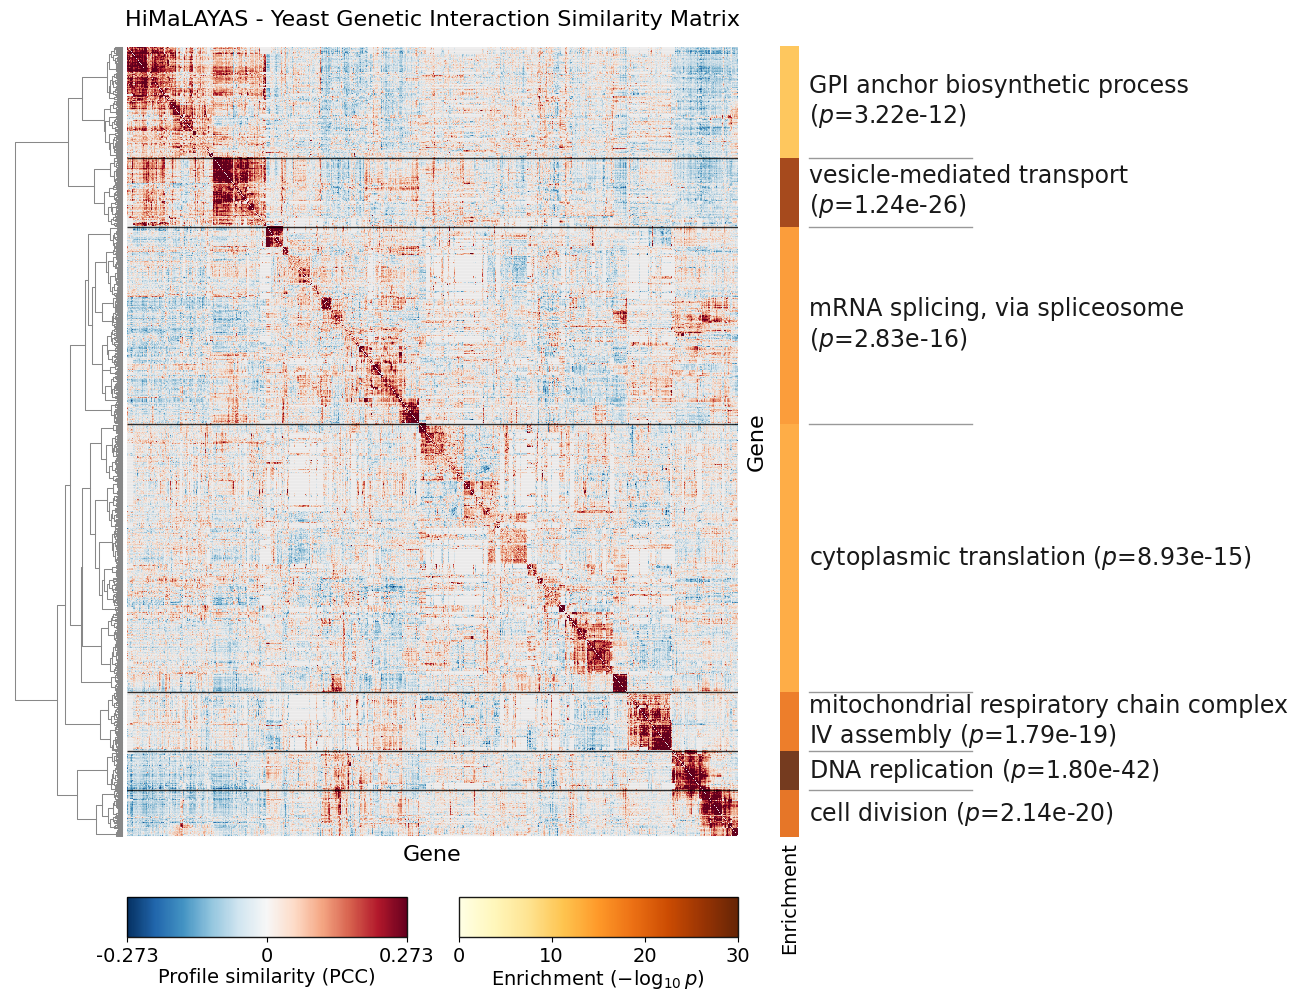

In [5]:
# Configure and render the annotated matrix

LABEL_COLOR = "black"
BACKGROUND_COLOR = "white"
FONT = "DejaVu Sans"

# Set color limits for the matrix
vals = matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

plotter = (
    Plotter(results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        "HiMaLAYAS - Yeast Genetic Interaction Similarity Matrix",
        color=LABEL_COLOR,
        font=FONT,
        fontsize=16,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.35,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(13, 10),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=16,
        font=FONT,
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="p",
        label_mode="top_term",
        max_words=24,
        wrap_text=True,
        wrap_width=40,
        overflow="wrap",
        font=FONT,
        fontsize=17,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label", "p"),
        label_prefix=None,
        boundary_color=LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
    )
    .plot_cluster_bar(
        norm=Normalize(0, 30),
        name="sigbar",
        title="Enrichment",
        width=0.04,
        left_pad=0.06,
        right_pad=0.01,
    )
    .plot_bar_labels(
        font=FONT,
        fontsize=14,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, 30),
        label=r"Enrichment ($-\log_{10}p$)",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.04,
        gap=0.06,
        label_pad=2.0,
        hpad=0.04,
        vpad=0.00,
        fontsize=14,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

plotter.show()

---

## Condensed Dendrogram

Summarize the same hierarchy with cluster-level labels and enrichment significance.


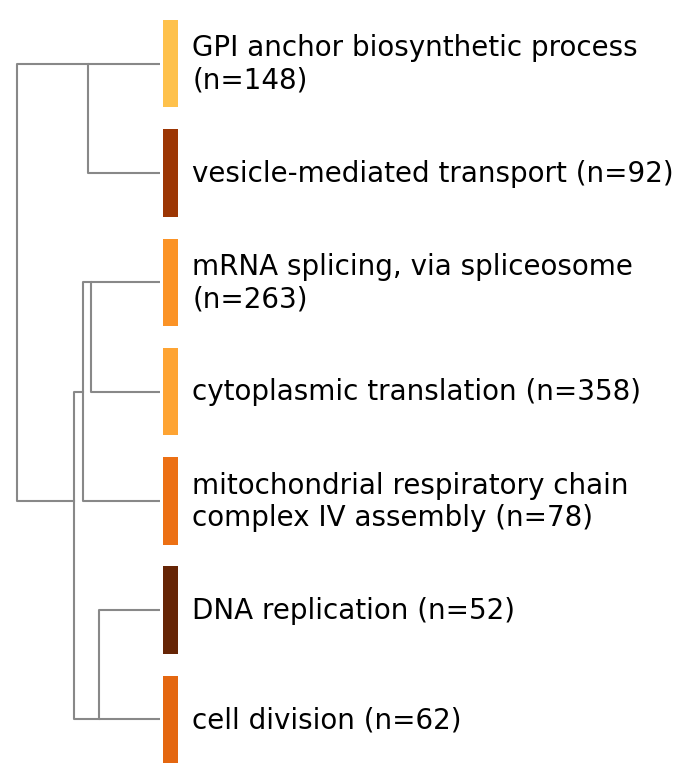

In [6]:
from himalayas.plot import plot_dendrogram_condensed

condensed = plot_dendrogram_condensed(
    results_sig,
    rank_by="p",
    label_mode="top_term",
    figsize=(2.5, 8.5),
    sigbar_cmap="YlOrBr",
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    font=FONT,
    fontsize=20,
    max_words=24,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n"),
    label_color=LABEL_COLOR,
    label_left_pad=0.06,
    dendrogram_color="#888888",
    dendrogram_lw=1.5,
    background_color=BACKGROUND_COLOR,
)

condensed.show()